## 4.3 极大极小设计

考虑式 (3.5) 中的最大熵准则：

$$
\max_D |\boldsymbol{R}|
\tag{4.13}
$$

设 $\lambda_1,\dots,\lambda_n$ 为矩阵 $\boldsymbol{R}$ 的特征值。根据几何均值恒小于算术均值的性质可得：

$$
\begin{align*}
|\boldsymbol{R}|&=\prod_{i=1}^n \lambda_i \le \left( \frac{1}{n}\sum_{i=1}^n \lambda_i \right)^n\\
&=\left( \frac{1}{n}tr\{\boldsymbol{R}\} \right)^n=1=|\boldsymbol{I}_n|
\end{align*}
$$

由此可知，最大熵准则的本质是让相关矩阵尽可能逼近单位矩阵，也就是尽可能最小化 $\boldsymbol{R}$ 的非对角元素。据此，式 (4.13) 的替代准则可写为：

$$
\min_D \|\boldsymbol{R}-\boldsymbol{I}_n\|_\alpha
\tag{4.14}
$$

式中 $\|\cdot\|_\alpha$ 代表 $L_\alpha$ 范数。相较于式 (4.13)，式 (4.14) 的优势在于其目标函数的计算复杂度为 $\mathcal{O}(n^2)$，而式 (4.13) 的计算复杂度为 $\mathcal{O}(n^3)$，这为优化计算带来了显著的运算优势。

考虑无穷范数。由于矩阵 $\boldsymbol{R}$ 为正定矩阵（针对绝大多数常用相关函数而言），式 (4.14) 可化为：

$$
\min_{D}\max_{i\neq j}|\boldsymbol{R}_{ij}| = \min_{D}\max_{i\neq j}\boldsymbol{R}_{ij}
\tag{4.15}
$$

若在式 (4.3) 中选用各向同性高斯相关函数，则：

$$
\begin{align*}
\max_{i\neq j}\boldsymbol{R}_{ij}
&= \max_{i\neq j}\exp\left(-\frac{\|\boldsymbol{x}_i-\boldsymbol{x}_j\|^2}{\theta^2}\right) \\
&= \exp\left(-\min_{i\neq j}\frac{\|\boldsymbol{x}_i-\boldsymbol{x}_j\|^2}{\theta^2}\right) \\
&= \exp\left(-4\frac{\psi^2(D)}{\theta^2}\right),
\end{align*}
$$

其中

$$
\psi(D) := \frac{1}{2}\min_{i\neq j}\|\boldsymbol{x}_i-\boldsymbol{x}_j\|
$$

被称作设计 $D$ 的分离距离（也叫填充半径）（法斯豪尔，2007，第 136 页）。能够最大化分离距离的设计称为极大极小距离设计，简称极大极小设计（约翰逊等人，1990 年），其表达式为：

$$
D^*= \argmax_{D}\min_{i\neq j}\|\boldsymbol{x}_i-\boldsymbol{x}_j\|
\tag{4.16}
$$

由此可知，极大极小设计的目标是最大化所有设计点两两之间的最小距离。该类设计能够最小化矩阵 $\boldsymbol{R}$ 非对角元的最大值，进而近似最大化设计的熵。从几何角度来看，极大极小设计尽可能分散样本点，以期完整填充整个试验区域 $\mathcal{X}$。结合上一节的加油站案例进行说明：采用极大极小布局设计时，任意两座加油站之间不会距离过近，通过拉开站点间距弱化彼此间的客源竞争，因此极大极小设计更加偏向供给方视角；与之相对，极小极大设计则更多站在消费者角度进行布局。

极大极小设计并非唯一。图 4.3 展示了两组具有相同分离距离的设计方案，但显然第一种设计更优，原因是该设计中仅有一组点对取到最小距离，而第二种设计存在两组这样的点对。我们将距离为 $2\psi(D)$ 的点对数量定义为该设计的（极大极小）指标。我们希望这一指标尽可能小，避免过多点位相互靠近。因此，可以将设计指标作为次级准则，对极大极小设计进行优化筛选。约翰逊等人（1990）证明了下述结论。

> **定理 4.2** 设相关函数 $R(\boldsymbol{u}, \boldsymbol{v}) = \rho k(d(\boldsymbol{u}, \boldsymbol{v}))$，其中 $d$ 为距离度量，$\rho$ 为递减函数，且 $k>0$。则当 $k \to \infty$ 时，最低指标的极大极小设计渐近等价于最大熵设计。

> **图 4.3** 两组包含 7 个样本点的设计方案，二者分离距离相同，但极大极小指标不同。

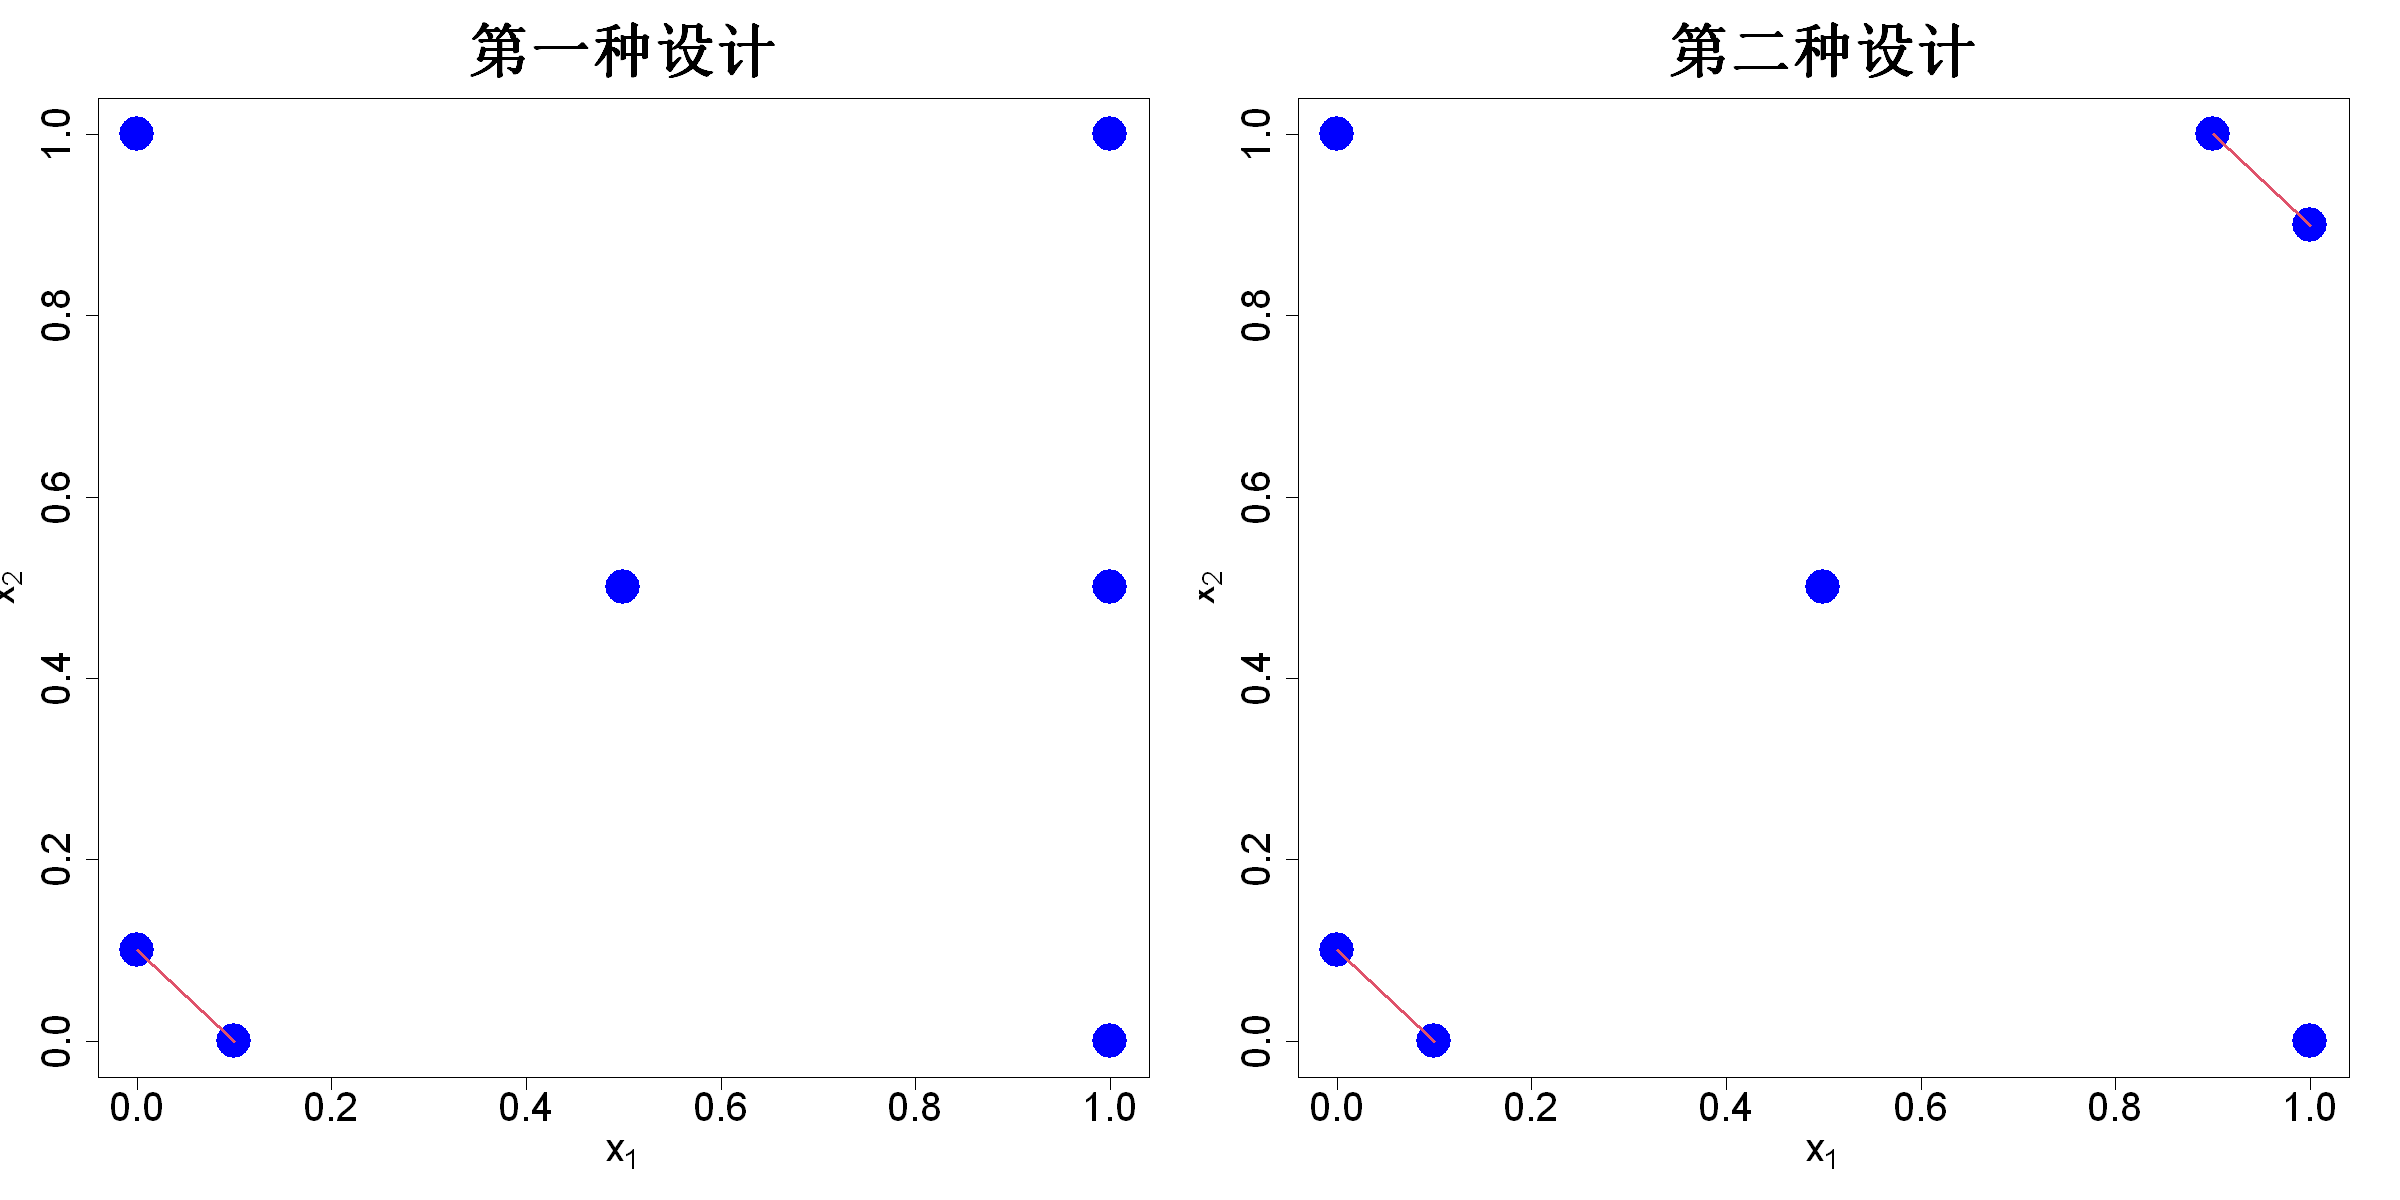

In [7]:
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
p=2;n=7
D=matrix(c(0,.1,.1,0,0,1,1,1,1,.5,1,0,.5,.5),nrow=n,ncol=p,byrow=TRUE)
plot(D,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue",cex=4,main="第一种设计",cex.main=3)
segments(0,.1,.1,0,col=2,lwd=3)

D=matrix(c(0,.1,.1,0,0,1,.9,1,1,.9,1,0,.5,.5),nrow=n,ncol=p,byrow=TRUE)
plot(D,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue",cex=4,main="第二种设计",cex.main=3)
segments(0,.1,.1,0,col=2,lwd=3)
segments(.9,1,1,.9,col=2,lwd=3)
par(mfrow=c(1,1))

接下来分析表 2.1 中的有理二次（RQ）相关函数（拉斯穆森、威廉姆斯，2006 年，第 86 页），该函数也被称作逆二次核或柯西核（法斯豪尔、麦考特，2015 年，第 42 页）：

$$
R(\boldsymbol{\Delta}) = \frac{1}{1+\frac{\|\boldsymbol{\Delta}\|^2}{\theta^2}}
\tag{4.17}
$$

于是式 (4.14) 中的目标函数可写为：

$$
\begin{align*}
\|\boldsymbol{R}-\boldsymbol{I}_n\|_\alpha^\alpha&=\sum_{i=1}^n\sum_{j\neq i}\frac{1}{\left({1+\frac{\|\boldsymbol{x}_i-\boldsymbol{x}_j\|^2}{\theta^2}}\right)^\alpha}\\
&\le\theta^{2\alpha}\sum_{i=1}^n\sum_{j\neq i}\frac{1}{\|\boldsymbol{x}_i-\boldsymbol{x}_j\|^{2\alpha}}
\end{align*}
$$

该上界中的第二项为总倒数距离（TRD），该指标的特点是不含参数 $\theta$，可作为式 (4.16) 的替代评判准则。不难看出，当 $\alpha$ 取值很大时：

$$
\begin{align*}
\min_D TRD(D)&=\min_D\sum_{i=1}^n\sum_{j\neq i}\frac{1}{\|\boldsymbol{x}_i-\boldsymbol{x}_j\|^{2\alpha}}
\tag{4.18}\\
&\approx\min_D\frac{I}{\min_{i\neq j}\|\boldsymbol{x}_i-\boldsymbol{x}_j\|^{2\alpha}}\\
&\equiv\max_{D}\frac{\min_{i\neq j}\|\boldsymbol{x}_i-\boldsymbol{x}_j\|}{I^{1/(2\alpha)}}
\end{align*}
$$

式中 $I$ 代表设计索引。因此当 $\alpha$ 足够大时，最小化总倒数距离 $TRD(D)$ 既能最大化样本点间的最小距离，还可实现设计索引最小化。由此可见，相较于式 (4.16) 中的极大极小准则，总倒数距离准则的表现更优（莫里斯、米切尔，1995 年）。而式 (4.16) 的优势在于其目标函数的计算复杂度为 $\mathcal{O}(n\log n)$，总倒数距离 $TRD(D)$ 的计算复杂度则为 $\mathcal{O}(n^2)$。当 $\alpha=1$ 时的总倒数距离准则由奥泽与埃格莱斯于 1977 年提出，该准则存在对应的物理模型：等价于最小化放置在方框内、质量相等粒子之间的万有引力。

与极小极大设计的情形类似，在一维问题中求解极大极小设计十分简便。含 $n$ 个试验点的极大极小设计表达式为：

$$
D=\left\{\frac{i-1}{n-1}\right\}_{i=1}^{n}
\tag{4.19}
$$

当维度 $p \ge 2$ 时，除非选取 $n=2p$ 这类特殊的样本量取值，否则求解极大极小设计将会变得十分困难。优化轨迹距离准则 $TRD(D)$ 的难度更低，其梯度表达式为：

$$
\frac{\partial TRD(D)}{\partial\boldsymbol{x}_k}=4\alpha\sum_{j\ne k}\frac{\boldsymbol{x}_j-\boldsymbol{x}_k}{\|\boldsymbol{x}_j-\boldsymbol{x}_k\|^{2\alpha+2}},\quad k = 1, \dots, n
$$

可基于该梯度开展梯度类优化运算。但由于 $TRD(D)$ 属于多峰函数，该优化过程极易收敛至局部最优解。因此，需要设置多组随机初始值，以此搜寻全局最优解。若要求解式 (4.16) 中的极大极小设计，可采用无导数全局优化算法；但当 $n$ 与 $p$ 数值较大时，该算法运算速度较慢。R 语言程序包 SFDesign（Wang、Joseph，2025c）中已实现该算法。

采用 SFDesign 构造得到的样本量 $n=7$、维度 $p=2$ 的极大极小设计如图 4.4 所示，其分离距离 $\psi(D^*)=0.26795$。以各个设计点为圆心、$\psi(D^*)$ 为半径绘制圆形。极大极小设计能够最大化可布置在每个设计点周围、互不重叠的相同球体半径，这一特性使得该问题与数学领域经典的球体装填问题密切相关（康威、斯隆，2013）。不过，绝大多数球体装填相关理论成果研究的是 $\mathbb{R}^p$ 空间内球体排布问题，而非本文研究的超立方体场景。边界约束条件致使极大极小设计与最优球体装填构型存在差异，但已有研究尝试借助球体装填的相关结论求解极大极小设计问题（何，2017b）。这类问题属于复杂数学难题，仅有部分特定情形存在简易解。正如博罗达乔夫等人（2019，第 11 页）所言：“三维欧氏空间中最优装填构型的证明历经近四百年悬而未决，但但凡堆叠过橙子的人，早已知晓答案。”如需查阅正方形与立方体上球体最优装填的相关结果及其参考文献，可访问网站：http://www.packomania.com/。

> **图 4.4** 包含 7 个样本点的极大极小设计。

r: 0.267948 


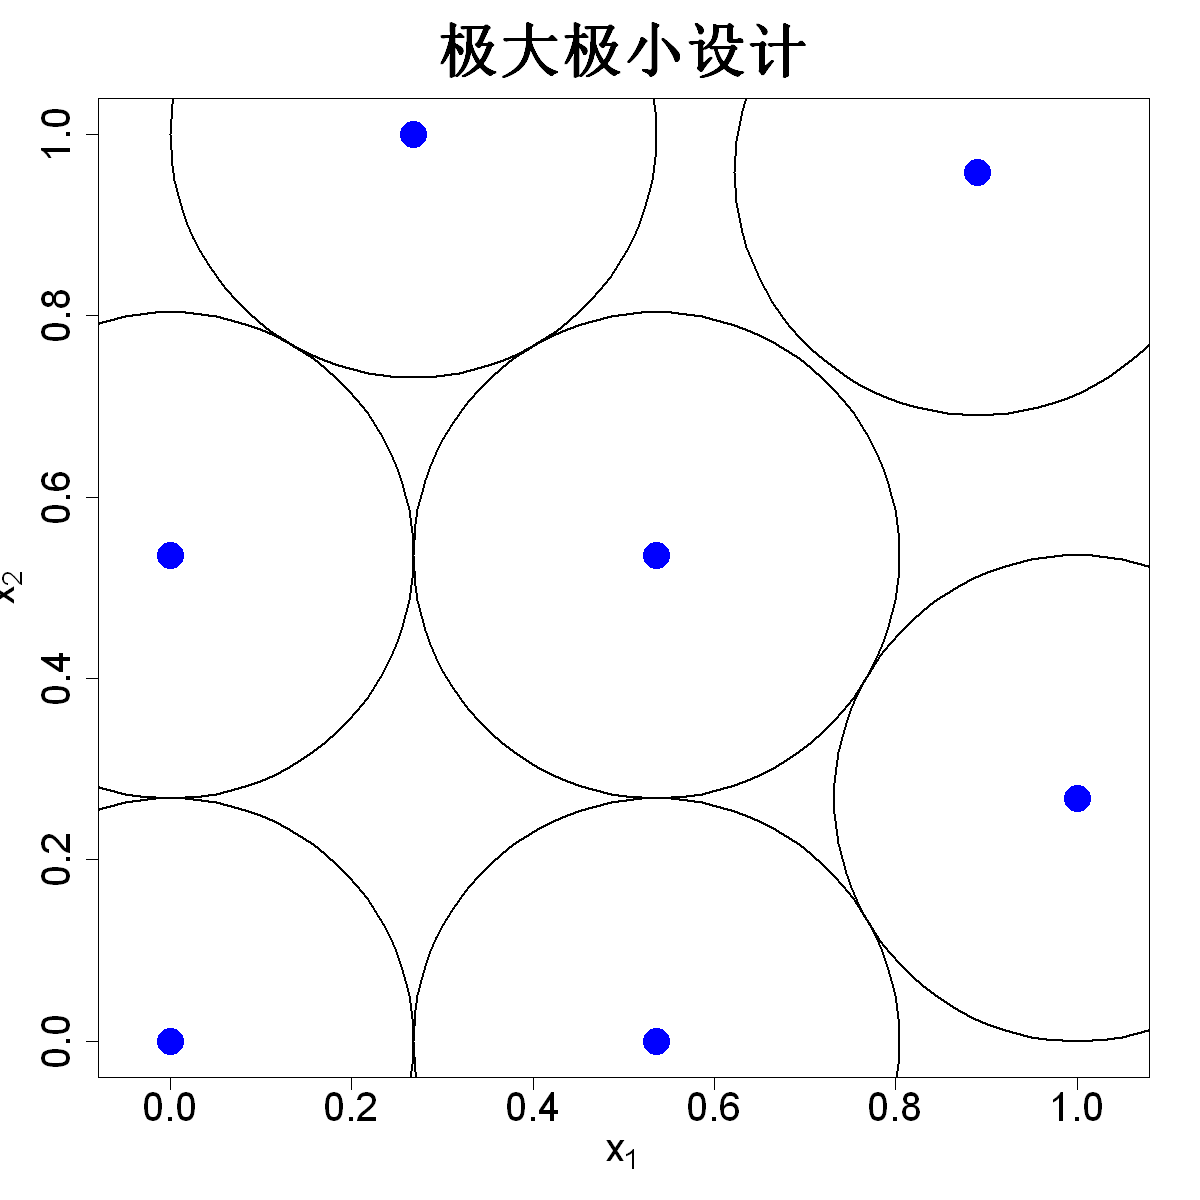

In [3]:
options(repr.plot.width=10,repr.plot.height=10)
p=2;n=7
set.seed(1)
library(SFDesign)
D=maximin.optim(maximinLHD(n,p)$design,sa=TRUE,find.best.ini=TRUE)$design
r=min(dist(D))/2
cat("r:",r,"\n")
plot(D,xlab=expression(x[1]),ylab=expression(x[2]),xlim=c(0,1),ylim=c(0,1),pch=16,col="blue",cex=3,cex.main=3,cex.lab=2,cex.axis=2,main="极大极小设计",asp=1)
library(plotrix)
for(i in 1:n)draw.circle(D[i,1],D[i,2],radius=r,lwd=2)

极大极小设计相较于聚类设计与极小极大设计的一大优势在于，其能够便捷地适配序贯构造流程。举例来说，我们可以先选取一个样本点 $\boldsymbol{x}_1$，随后按照下述公式依次新增 $\boldsymbol{x}_2,\dots,\boldsymbol{x}_n$：

$$
\boldsymbol{x}_{k+1}=\argmax_{\boldsymbol{x}\in X}\;\min_{i=1:k}\|\boldsymbol{x}-\boldsymbol{x}_i\|,\quad k=1,\dots,n-1 \tag{4.20}
$$

该方法最早由肯纳德与斯通于 1969 年提出，用于物理实验设计。尚与阿普利在 2021 年针对该算法提出了多种变体形式与优化方案。需要注意的是，上述方法属于初始设计的序贯构造方法，而第七章将要介绍的序贯设计方法，是在完整获取所有包含响应值在内的数据之后再开展设计工作。

图 4.5 左图展示了依据最大最小准则，向中心点依次新增六个样本点的过程。该过程可借助 SFDesign 软件包中的 maximin.augment 函数实现（王与约瑟夫，2025c）。最终生成设计的最小间距 $\psi(D)=0.25$，小于图 4.4 中最优最大最小设计的最小间距。在此设计基础上继续依次追加六个样本点，即可得到图 4.5 右侧图形对应的设计方案，该方案表现优良，但并非包含 13 个样本点的最优最大最小设计。

> **图 4.5** 左侧图像展示了以中心点为初始点、逐步构建而成的最大最小距离设计。右侧图像呈现依据最大最小准则，在该设计基础上新增六个点位（红色十字标记）扩充后的设计方案。

r1: 0.25 
r2: 0.1767767 


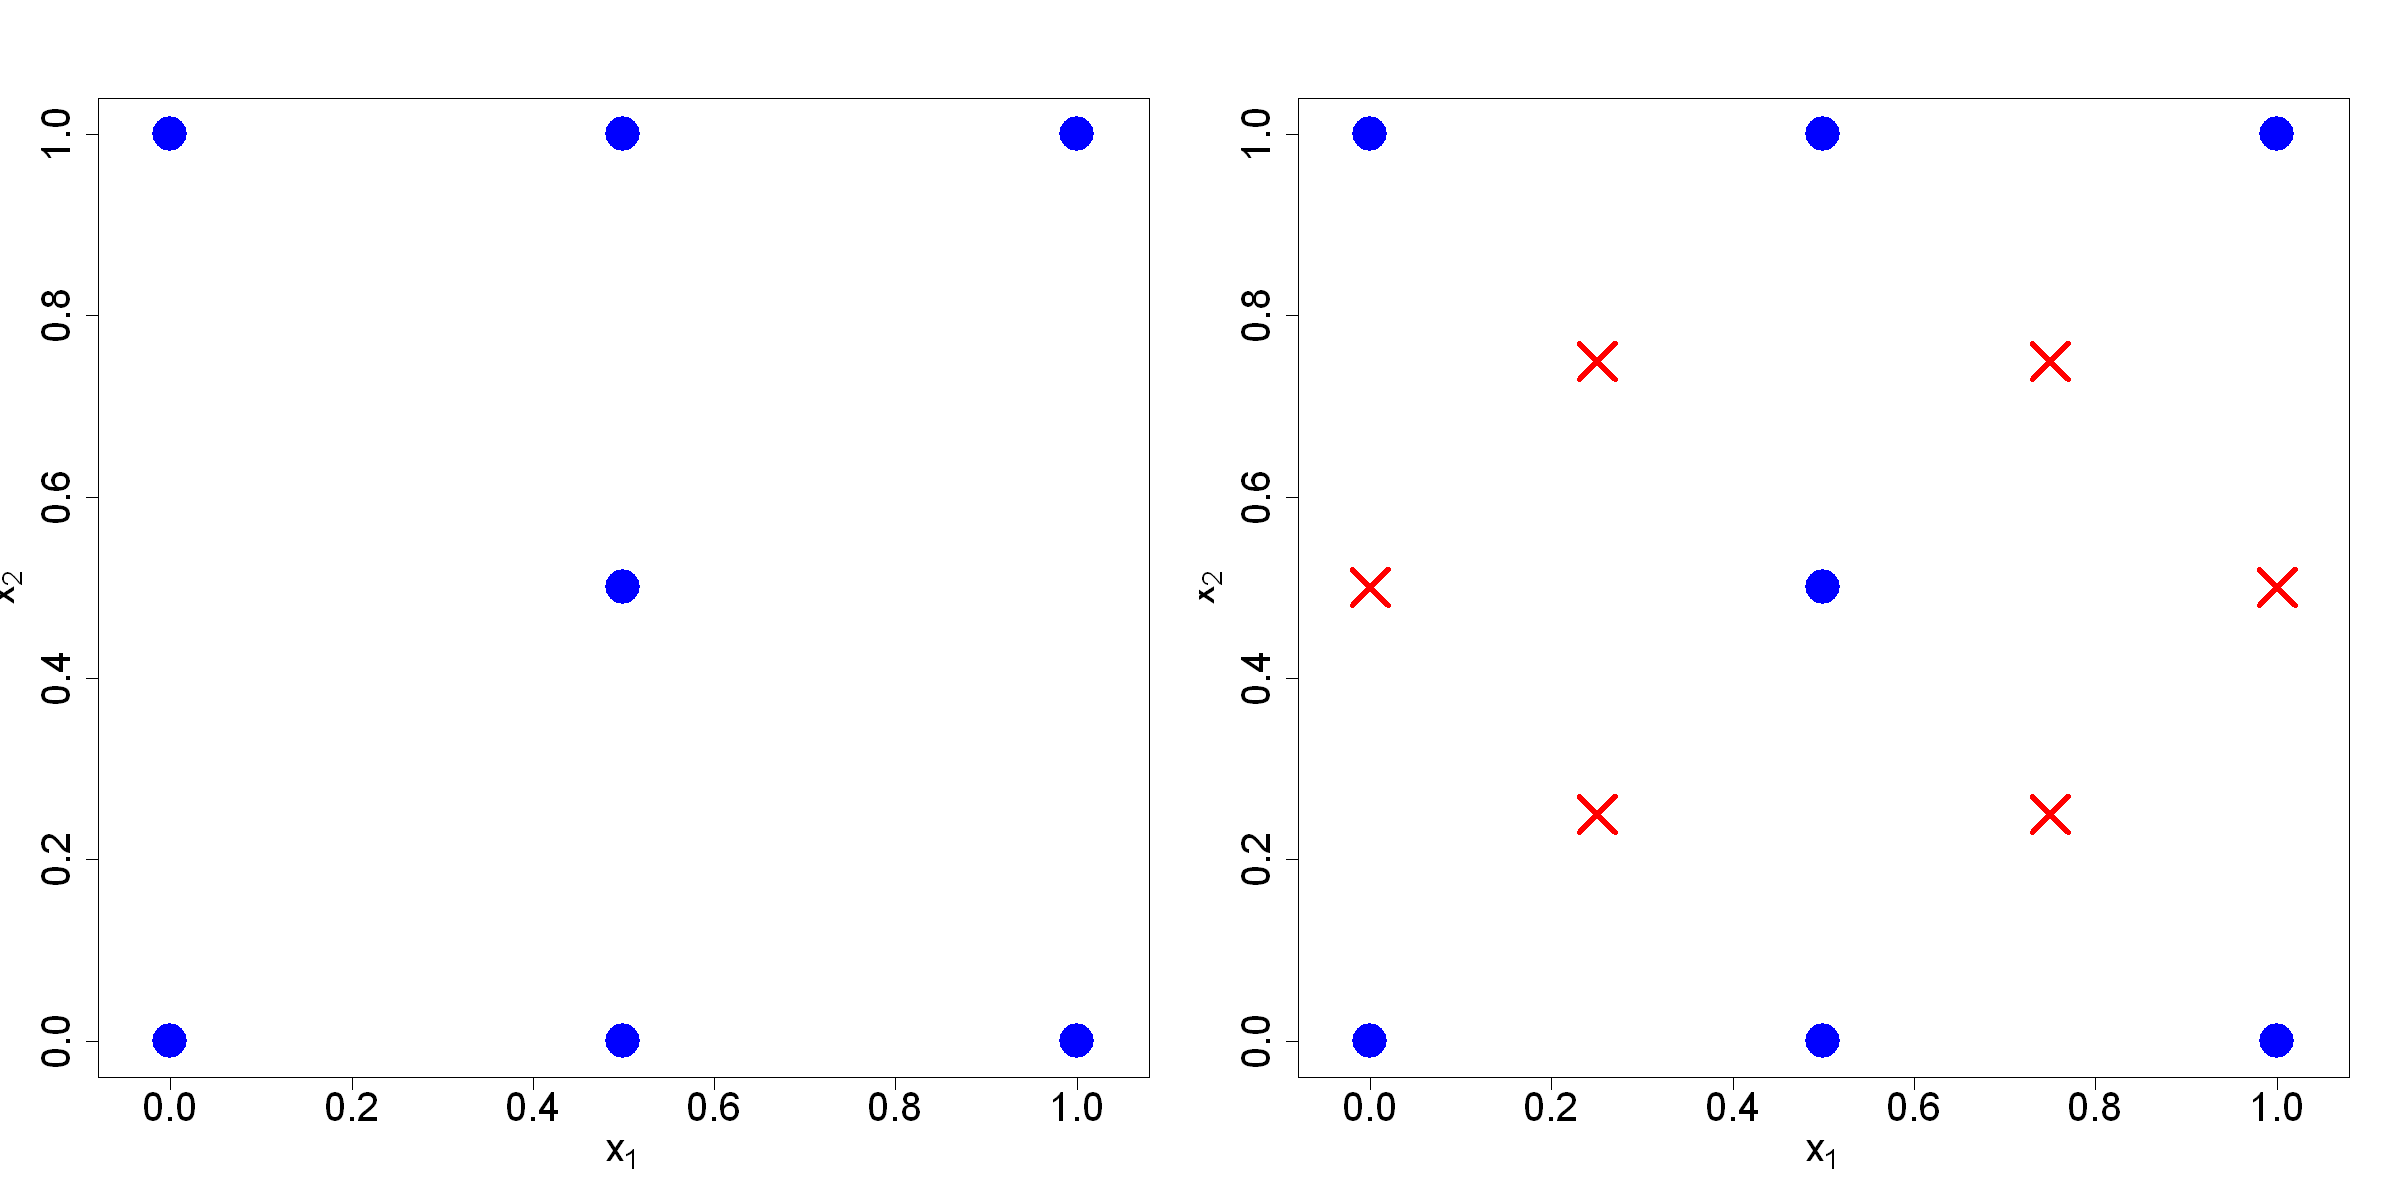

In [14]:
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
p=2;n=7
set.seed(1)
library(SFDesign)
CAND=full.factorial(p=2,level=5)
D=maximin.augment(n=7,p=2,D.ini=matrix(c(.5,.5),nrow=1,ncol=p),candidate=CAND)
cat("r1:",min(dist(D))/2,"\n")
plot(D,xlim=c(0,1),ylim=c(0,1),cex=4,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue",asp=1)
plot(D,xlim=c(0,1),ylim=c(0,1),cex=4,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue",asp=1)
D2=maximin.augment(n=13,p=2,D.ini=D,candidate=CAND)
cat("r2:",min(dist(D2))/2,"\n")
points(D2[8:13,],cex=4,lwd=5,pch=4,col="red")
par(mfrow=c(1,1))